<a href="https://colab.research.google.com/github/bahmanravaei/tutorial-for-ML/blob/Classification/Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Decision Tree

## Load iris dataset

In [16]:
"""
Created on Mon Mar  6 21:40:39 2023

@author: bahman
"""
from sklearn import datasets
irisdata=datasets.load_iris()
X=irisdata.data
y=irisdata.target

## Divide dataset to train_X, test_X, train_y and test_y

In [17]:
#### TRAIN TEST SPLIT ####
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.25)

## Create learning model with decision tree, then train model

In [18]:
#### CREATE MODEL AND TRAIN IT ####

from sklearn.tree import DecisionTreeClassifier
DTC = DecisionTreeClassifier()

model = DTC.fit(train_X, train_y)


## Evaluation of model

Confusion Matrix: 


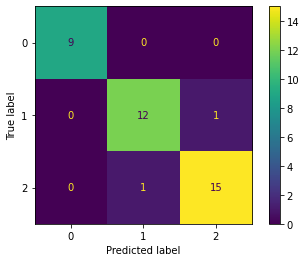

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
predicted_y=model.predict(test_X)
cm=confusion_matrix(test_y,predicted_y)

print ('Confusion Matrix: ')


disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=DTC.classes_)
disp.plot()
plt.show()

In [20]:
from sklearn.metrics import accuracy_score
print (accuracy_score(test_y, predicted_y)*100, '%')


94.73684210526315 %


## Feature Importance

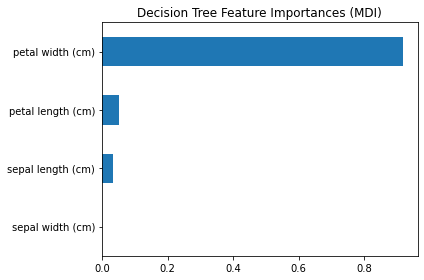

In [21]:
from sklearn.inspection import permutation_importance

feature_names = irisdata.feature_names

mdi_importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=True)

ax = mdi_importances.plot.barh()
ax.set_title("Decision Tree Feature Importances (MDI)")
ax.figure.tight_layout()

## Visualising Tree structure

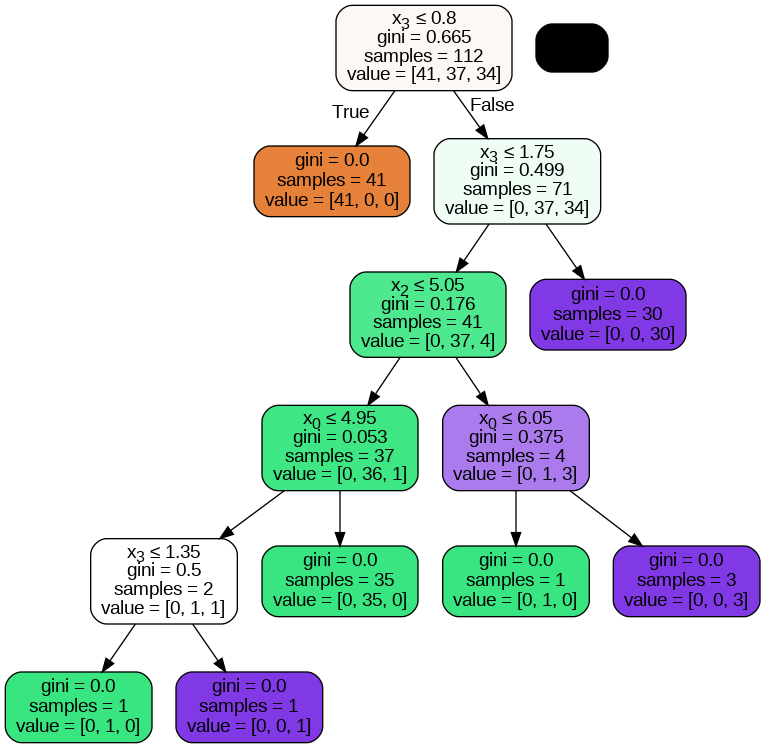

In [22]:

from six import StringIO

from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(model, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())